In [2]:
import seaborn as sns
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [3]:
tips.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [4]:
tips.tail(10)

,total_bill,tip,sex,smoker,day,time,size
234,15.53,3.00,Male,Yes,Sat,Dinner,2
235,10.07,1.25,Male,No,Sat,Dinner,2
236,12.60,1.00,Male,Yes,Sat,Dinner,2
237,32.83,1.17,Male,Yes,Sat,Dinner,2
238,35.83,4.67,Female,No,Sat,Dinner,3
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [5]:
tips.shape

(244, 7)

In [6]:
cols = list(tips.columns)
type(cols)

list

### Find missing values.

In [7]:
df = tips
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

### Generate summary statistics.

In [8]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

### Show only total_bill and tip.

In [10]:
df[['total_bill','tip']]

,total_bill,tip
0,16.99,1.01
1,10.34,1.66
2,21.01,3.50
3,23.68,3.31
4,24.59,3.61
...,...,...
239,29.03,5.92
240,27.18,2.00
241,22.67,2.00
242,17.82,1.75


### Find customers who paid more than $30.

In [11]:
a = df[df['total_bill']>30]
a.shape

(32, 7)

### Find smokers who visited on Sunday.

In [12]:
s = df[(df['smoker']=='Yes') & (df['day']=='Sun')]
s

,total_bill,tip,sex,smoker,day,time,size
164,17.51,3.00,Female,Yes,Sun,Dinner,2
172,7.25,5.15,Male,Yes,Sun,Dinner,2
173,31.85,3.18,Male,Yes,Sun,Dinner,2
174,16.82,4.00,Male,Yes,Sun,Dinner,2
175,32.90,3.11,Male,Yes,Sun,Dinner,2
176,17.89,2.00,Male,Yes,Sun,Dinner,2
177,14.48,2.00,Male,Yes,Sun,Dinner,2
178,9.60,4.00,Female,Yes,Sun,Dinner,2
179,34.63,3.55,Male,Yes,Sun,Dinner,2
180,34.65,3.68,Male,Yes,Sun,Dinner,4


### Find records where tip > 5.

In [13]:
t = df[df['tip']>5]
t

,total_bill,tip,sex,smoker,day,time,size
23,39.42,7.58,Male,No,Sat,Dinner,4
44,30.40,5.60,Male,No,Sun,Dinner,4
47,32.40,6.00,Male,No,Sun,Dinner,4
52,34.81,5.20,Female,No,Sun,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
85,34.83,5.17,Female,No,Thur,Lunch,4
88,24.71,5.85,Male,No,Thur,Lunch,2
116,29.93,5.07,Male,No,Sun,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6
155,29.85,5.14,Female,No,Sun,Dinner,5


### Calculate: Average bill Average tip Maximum bill Minimum bill

In [14]:
avg_bill = df['total_bill'].mean()
print(avg_bill)
avg_tips=df['tip'].mean()
print(avg_tips)
print(f"max bill {df['total_bill'].max()}")
print(f"min bill {df['total_bill'].min()}")

19.78594262295082
2.99827868852459
max bill 50.81
min bill 3.07


### Find average tip by gender.

In [15]:
df.groupby('sex')['tip'].mean().to_frame('avg_tip')

/var/folders/2t/syh9gx9j08vcd5w3tz6mjzlr0000gn/T/ipykernel_779/2927195343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')['tip'].mean().to_frame('avg_tip')


,avg_tip
sex,
Male,3.089618
Female,2.833448


### Find average bill by day.

In [16]:
df.groupby('day')['total_bill'].mean().to_frame('avg_bill')

/var/folders/2t/syh9gx9j08vcd5w3tz6mjzlr0000gn/T/ipykernel_779/2667710023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['total_bill'].mean().to_frame('avg_bill')


,avg_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


### Find average tip by time (Lunch/Dinner).

In [17]:
df.groupby('day')['total_bill'].mean().to_frame('avg_bill')

/var/folders/2t/syh9gx9j08vcd5w3tz6mjzlr0000gn/T/ipykernel_779/2667710023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['total_bill'].mean().to_frame('avg_bill')


,avg_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


### Count customers for each day.

In [18]:
df.groupby('day')['total_bill'].count().to_frame('customer_count')

/var/folders/2t/syh9gx9j08vcd5w3tz6mjzlr0000gn/T/ipykernel_779/1072790362.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('day')['total_bill'].count().to_frame('customer_count')


,customer_count
day,
Thur,62
Fri,19
Sat,87
Sun,76


### Create a new column called tip_percentage 

In [19]:
tips['tip_percentage'] = (tips['tip']/tips['total_bill'])*100

### Sort by total bill descending.

In [20]:
df.sort_values(by='total_bill', ascending=False)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.681165
212,48.33,9.00,Male,No,Sat,Dinner,4,18.621974
59,48.27,6.73,Male,No,Sat,Dinner,4,13.942407
156,48.17,5.00,Male,No,Sun,Dinner,6,10.379905
182,45.35,3.50,Male,Yes,Sun,Dinner,3,7.717751
...,...,...,...,...,...,...,...,...
149,7.51,2.00,Male,No,Thur,Lunch,2,26.631158
111,7.25,1.00,Female,No,Sat,Dinner,1,13.793103
172,7.25,5.15,Male,Yes,Sun,Dinner,2,71.034483
92,5.75,1.00,Female,Yes,Fri,Dinner,2,17.391304


### Sort by tip percentage descending.

In [21]:
df.sort_values(by='tip_percentage', ascending=False)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
172,7.25,5.15,Male,Yes,Sun,Dinner,2,71.034483
178,9.60,4.00,Female,Yes,Sun,Dinner,2,41.666667
67,3.07,1.00,Female,Yes,Sat,Dinner,1,32.573290
232,11.61,3.39,Male,No,Sat,Dinner,2,29.198966
183,23.17,6.50,Male,Yes,Sun,Dinner,4,28.053517
...,...,...,...,...,...,...,...,...
187,30.46,2.00,Male,Yes,Sun,Dinner,5,6.565988
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
57,26.41,1.50,Female,No,Sat,Dinner,2,5.679667
102,44.30,2.50,Female,Yes,Sat,Dinner,3,5.643341


### Find top 5 highest bills.

In [24]:
df.sort_values(by=['day','total_bill'], ascending=[True, False]).head(5)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
197,43.11,5.00,Female,Yes,Thur,Lunch,4,11.598237
142,41.19,5.00,Male,No,Thur,Lunch,5,12.138869
85,34.83,5.17,Female,No,Thur,Lunch,4,14.843526
141,34.30,6.70,Male,No,Thur,Lunch,6,19.533528
83,32.68,5.00,Male,Yes,Thur,Lunch,2,15.299878


### Find top 5 highest tippers.

In [25]:
df.sort_values(by=['tip'], ascending=False).head(5)

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
170,50.81,10.00,Male,Yes,Sat,Dinner,3,19.681165
212,48.33,9.00,Male,No,Sat,Dinner,4,18.621974
23,39.42,7.58,Male,No,Sat,Dinner,4,19.228818
59,48.27,6.73,Male,No,Sat,Dinner,4,13.942407
141,34.30,6.70,Male,No,Thur,Lunch,6,19.533528


### Line plot of total_bill.

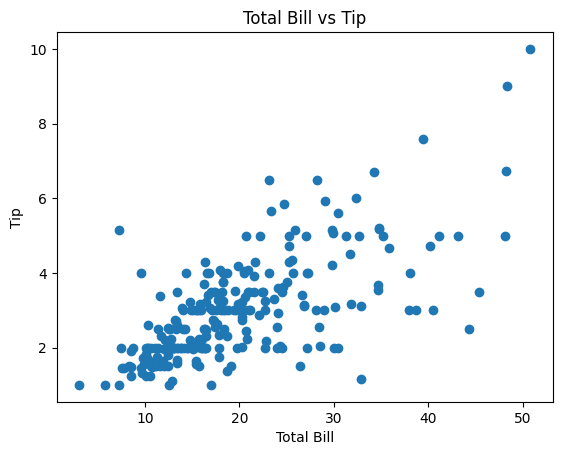

In [32]:
import matplotlib.pyplot as plt
plt.scatter(df['total_bill'], df['tip'])
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Total Bill vs Tip")
plt.show()

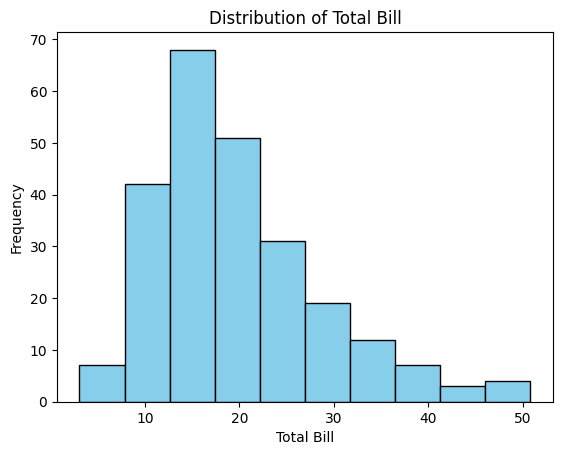

In [37]:
# Histogram of total_bill.
plt.hist(df['total_bill'], bins=10, edgecolor='black', color='skyblue', density=False)
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.title('Distribution of Total Bill')
plt.show()

### Histogram of tip.

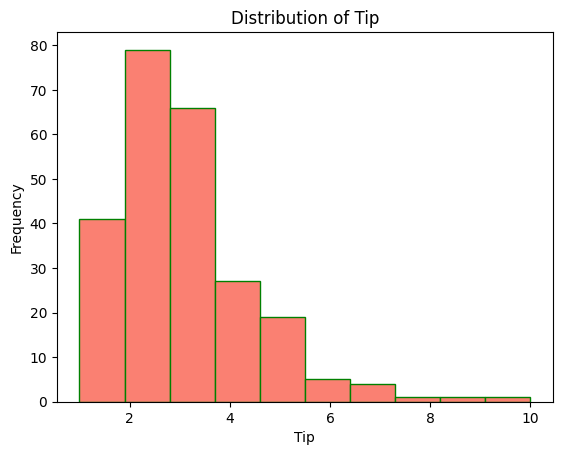

In [41]:
plt.hist(df['tip'], bins=10, edgecolor='green', color='salmon', density=False,)
plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Distribution of Tip')
plt.show()